## **Farmland Birds Under Pressure**
# Biodiversity Trends and Agricultural Change in Europe

**Main question**

**How have common farmland-bird populations changed across European countries since 2000, and are agricultural intensity, organic farming and protected-area coverage associated with different national trajectories?**

**Layer 1:** Long-term biodiversity trends

Use:

- env_bio2: national farmland-bird indices
- env_bio3: EU bird-group indices and uncertainty

Source: https://ec.europa.eu/eurostat/web/main/data/database#Updates


**Period:**

1990–2019 for Germany and long-term countries
2000–2019 for the main cross-country comparison
Later years only in a clearly labelled supplementary analysis

**Questions:**

- Which countries experienced the largest decline since 2000?
- Did Germany decline faster than the EU benchmark?
- Are farmland birds declining faster than forest birds?
- Are there countries showing stabilization or recovery?
- How sensitive are rankings to the chosen endpoint?

 **Bird groups**
CO_ALL: all common bird species
CO_FARM: common farmland bird species
CO_FOR: common forest bird species

**Estimate types**
NSME: unsmoothed estimate
SME: smoothed estimate
SME_LW95: lower 95% confidence limit
SME_UP95: upper 95% confidence limit

 **Index reference systems**
I00: 2000 = 100
I90: 1990 = 100
I_LY: latest year = 100


**Layer 2: Environmental drivers**
Add three Eurostat indicators.

1. Organic farming

Dataset:[Area under organic farming — sdg_02_40](https://ec.europa.eu/eurostat/databrowser/view/tag00025/default/table?lang=en)

## 1. Load the Eurostat bulk-download files

Eurostat's TSV files are compressed with gzip. Pandas can read them directly; manual decompression is unnecessary. The path resolver below works both next to the notebook and in the original Google Drive folder.


In [1]:
# Loading files .tsv.gz from GitHub
!wget https://raw.githubusercontent.com/fisicangel/Farmland_birds_under_pressure_Final_Project/main/Data_Eurostat/estat_env_bio2.tsv.gz
!wget https://raw.githubusercontent.com/fisicangel/Farmland_birds_under_pressure_Final_Project/main/Data_Eurostat/estat_env_bio3.tsv.gz
!wget https://raw.githubusercontent.com/fisicangel/Farmland_birds_under_pressure_Final_Project/main/Data_Eurostat/estat_env_bio4.tsv.gz

print("Files correctly loanded")

--2026-09-15 08:16:04--  https://raw.githubusercontent.com/fisicangel/Farmland_birds_under_pressure_Final_Project/main/Data_Eurostat/estat_env_bio2.tsv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2203 (2.2K) [application/octet-stream]
Saving to: ‘estat_env_bio2.tsv.gz’

estat_env_bio2.tsv. 100%[===================>]   2.15K  --.-KB/s    in 0s      

2026-09-15 08:16:04 (30.7 MB/s) - ‘estat_env_bio2.tsv.gz’ saved [2203/2203]

--2026-09-15 08:16:04--  https://raw.githubusercontent.com/fisicangel/Farmland_birds_under_pressure_Final_Project/main/Data_Eurostat/estat_env_bio3.tsv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubuser

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


def find_data_file(filename):
    # Return the first existing copy of a source file.
    candidates = [
        Path(filename),
        Path(filename + ".1"), # Added to check for files downloaded with .1 suffix
        Path("upload") / filename,
        Path("upload") / (filename + ".1"), # Added to check for files with .1 suffix in 'upload' directory
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    searched = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")


source_paths = {
    "env_bio2": find_data_file("estat_env_bio2.tsv.gz"),
    "env_bio3": find_data_file("estat_env_bio3.tsv.gz"),
    "env_bio4": find_data_file("estat_env_bio4.tsv.gz"),
}

raw_bio2 = pd.read_csv(source_paths["env_bio2"], sep="\t", compression="gzip", dtype=str)
raw_bio3 = pd.read_csv(source_paths["env_bio3"], sep="\t", compression="gzip", dtype=str)
raw_bio4 = pd.read_csv(source_paths["env_bio4"], sep="\t", compression="gzip", dtype=str)

display(raw_bio2.head(), raw_bio3.head(), raw_bio4.head())

pd.DataFrame(
    {
        "dataset": source_paths.keys(),
        "rows": [len(raw_bio2), len(raw_bio3), len(raw_bio4)],
        "columns": [raw_bio2.shape[1], raw_bio3.shape[1], raw_bio4.shape[1]],
        "source_file": [str(path) for path in source_paths.values()],
    }
)

,"freq,unit,geo\TIME_PERIOD",1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"A,I00,AT",:,:,:,:,:,:,:,:,100.00,102.30,98.50 d,91.30 d,92.80 d,87.80 d,...,70.30 d,67.70 d,68.70 d,63.00 d,59.80 d,62.90 d,58.40 d,60.70 d,55.20 d,61.50 d,61.70 d,60.50 d,:,:,:
1,"A,I00,BE",149.09,142.38,136.17,130.38,124.98,119.95,115.32,111.08,107.13,103.42,100.00,96.95,94.36,92.16,...,81.20,78.39,75.52,72.88,70.43,67.96,65.53,63.18,60.93,58.75,56.62,:,:,:,:
2,"A,I00,CH",118.92,112.30,113.12,114.63,114.98,112.34,108.66,100.62,96.47,96.47,100.00,92.58,88.62,89.96,...,94.09,97.04,102.88,94.97,99.13,100.00,101.87,101.00,99.48,105.65,117.65,119.19,115.61,116.39,:
3,"A,I00,CY",:,:,:,:,:,:,:,:,:,:,:,:,:,:,...,81.00 d,85.00 d,91.00 d,123.00 d,98.00 d,117.00 d,132.00 d,110.00 d,117.00 d,123.00 d,120.00 d,110.00 d,81.00 d,:,:
4,"A,I00,CZ",112.68,121.44,129.46,135.42,138.75,138.06,130.19,117.86,106.83,100.71,100.00,98.19,96.46,94.83,...,83.39,81.59,79.79,78.00,76.20,74.37,72.54,70.72,68.93,67.16,65.41,63.67,61.94,60.23,:


,"freq,statinfo,comspec,unit,geo\TIME_PERIOD",1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"A,NSME,CO_ALL,I00,EU27_2020",107.81,106.83,105.44,106.55,107.54,103.76,102.08,101.06,97.54,99.18,96.58,99.16,95.98,96.13,...,90.3,91.93,91.13,88.09,90,92.38,91.54,90.84,83.44,86.79,87.86,86.76,84.27,85.58,85.38
1,"A,NSME,CO_ALL,I90,EU27_2020",105.26,104.29,102.94,103.96,104.91,101.19,99.59,98.6,95.17,96.8,94.26,96.78,93.68,93.78,...,88.06,89.69,89,85.92,87.89,90.23,89.33,88.75,81.39,84.72,85.82,84.62,82.24,83.59,83.24
2,"A,NSME,CO_ALL,I_LY,EU27_2020",127.11,125.87,124.21,125.54,126.8,122.12,120.23,119.12,114.83,116.85,113.74,116.88,113.11,113.28,...,106.31,108.33,107.4,103.79,106.08,108.93,107.91,107.13,98.3,102.31,103.52,102.23,99.27,100.89,100.51
3,"A,NSME,CO_FARM,I00,EU27_2020",113.9,112.14,117.47,116.36,113.24,105.71,106.21,105.4,101.79,102.88,99.27,97.72,90.89,92.5,...,83.86,84.78,82.74,79.64,80.93,81.61,82.51,75.09,70.92,73.3,74.3,73.17,67.73,67.43,69.94
4,"A,NSME,CO_FARM,I90,EU27_2020",98.54,97.17,101.67,100.81,98.26,91.53,91.78,91.57,88.18,89.22,85.92,84.53,78.53,79.75,...,72.5,73.17,71.59,68.68,70.11,70.17,71.42,64.81,61.17,63.5,64.18,63.24,58.62,58.19,60.45


,"freq,unit,areaprot,geo\TIME_PERIOD",2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,"A,KM2,MPA,AT",:,: m,:,:,:,: m,:,:,: m,:,: m,: m,: m
1,"A,KM2,MPA,BE",:,1273,:,:,:,1274,:,:,1274,:,1322,1320 b,1332
2,"A,KM2,MPA,BG",:,995,:,:,:,2834,:,:,2834,:,2856,2857 b,2891
3,"A,KM2,MPA,CY",:,131,:,:,:,131,:,:,8463,:,8463,8481 b,8518
4,"A,KM2,MPA,CZ",:,: m,:,:,:,: m,:,:,: m,:,: m,: m,: m


,dataset,rows,columns,source_file
0,env_bio2,25,36,estat_env_bio2.tsv.gz
1,env_bio3,36,36,estat_env_bio3.tsv.gz
2,env_bio4,112,14,estat_env_bio4.tsv.gz


## 2. Parse Eurostat dimensions, values, and flags

The first column is not one variable. It contains several comma-separated dimensions, while `\TIME_PERIOD` marks the boundary between those dimensions and the year columns.

The raw missing-value check can be misleading: Eurostat represents missing observations with `:` rather than a conventional null. Cells can also contain a number followed by a status flag, for example `60.84 d`. The function below:

1. separates the first column into named dimensions;
2. reshapes years from columns into rows;
3. extracts the numeric observation;
4. keeps Eurostat's status flag in a separate column; and
5. converts `:` to a true missing value.


In [3]:
def eurostat_to_long(raw_df, dimension_names, dataset_name):
    # Convert a Eurostat bulk TSV table to tidy long format.
    id_column = raw_df.columns[0]
    expected_dimensions = len(dimension_names)

    dimensions = raw_df[id_column].str.split(",", expand=True)
    if dimensions.shape[1] != expected_dimensions:
        raise ValueError(
            f"{dataset_name}: expected {expected_dimensions} dimensions "
            f"but found {dimensions.shape[1]}"
        )
    dimensions.columns = dimension_names

    separated = pd.concat(
        [dimensions, raw_df.drop(columns=id_column)],
        axis=1,
    )

    tidy = separated.melt(
        id_vars=dimension_names,
        var_name="year",
        value_name="raw_value",
    )

    tidy["year"] = pd.to_numeric(tidy["year"].str.strip(), errors="raise").astype("int64")
    tidy["raw_value"] = tidy["raw_value"].astype("string").str.strip()

    extracted = tidy["raw_value"].str.extract(
        r"^(?:([-+]?\d+(?:\.\d+)?)|:)\s*([A-Za-z]+)?$"
    )
    tidy["value"] = pd.to_numeric(extracted[0], errors="coerce")
    tidy["flag"] = extracted[1].astype("string")
    tidy["dataset"] = dataset_name

    unexpected = tidy.loc[
        ~tidy["raw_value"].str.match(
            r"^(?:([-+]?\d+(?:\.\d+)?)|:)\s*([A-Za-z]+)?$",
            na=False,
        ),
        "raw_value",
    ].drop_duplicates()
    if not unexpected.empty:
        raise ValueError(f"{dataset_name}: unparsed cells: {unexpected.tolist()}")

    return tidy[
        ["dataset", *dimension_names, "year", "value", "flag", "raw_value"]
    ].sort_values([*dimension_names, "year"], ignore_index=True)


bio2_long = eurostat_to_long(
    raw_bio2,
    ["frequency", "unit", "country"],
    "env_bio2",
)

bio3_long = eurostat_to_long(
    raw_bio3,
    ["frequency", "estimate_type", "bird_group", "unit", "country"],
    "env_bio3",
)

bio4_long = eurostat_to_long(
    raw_bio4,
    ["frequency", "unit", "protected_area_type", "country"],
    "env_bio4",
)

bio2_long.head()


,dataset,frequency,unit,country,year,value,flag,raw_value
0,env_bio2,A,I00,AT,1990,<NA>,<NA>,:
1,env_bio2,A,I00,AT,1991,<NA>,<NA>,:
2,env_bio2,A,I00,AT,1992,<NA>,<NA>,:
3,env_bio2,A,I00,AT,1993,<NA>,<NA>,:
4,env_bio2,A,I00,AT,1994,<NA>,<NA>,:


## 3. Validate the tidy datasets

Duplicates should be checked using the dimensions that uniquely identify an observation, not across the original wide rows. Missing observations should be counted after `:` has been converted to `NaN`.


In [4]:
def dataset_audit(df, key_columns):
    return {
        "rows": len(df),
        "valid_values": int(df["value"].notna().sum()),
        "missing_values": int(df["value"].isna().sum()),
        "flagged_values": int(df["flag"].notna().sum()),
        "duplicate_keys": int(df.duplicated(key_columns).sum()),
        "first_year": int(df["year"].min()),
        "last_year": int(df["year"].max()),
    }


audit = pd.DataFrame.from_dict(
    {
        "env_bio2": dataset_audit(
            bio2_long, ["frequency", "unit", "country", "year"]
        ),
        "env_bio3": dataset_audit(
            bio3_long,
            ["frequency", "estimate_type", "bird_group", "unit", "country", "year"],
        ),
        "env_bio4": dataset_audit(
            bio4_long,
            ["frequency", "unit", "protected_area_type", "country", "year"],
        ),
    },
    orient="index",
).rename_axis("dataset").reset_index()

audit


,dataset,rows,valid_values,missing_values,flagged_values,duplicate_keys,first_year,last_year
0,env_bio2,875,643,232,157,0,1990,2024
1,env_bio3,1260,1260,0,0,0,1990,2024
2,env_bio4,1456,1004,452,106,0,2011,2023


## 4. Select the variables needed for the study

### National farmland-bird series (`env_bio2`)

This dataset is already restricted to the annual index with 2000 as its reference. Missing observations are removed from the analytical subset, but flagged observations are retained so that sensitivity checks remain possible.

### EU benchmark (`env_bio3`)

We select common farmland species and the 2000-based index. The unsmoothed estimate, smoothed estimate, and its lower and upper 95% confidence limits are pivoted into separate columns. This produces one EU row per year.

### Protected areas (`env_bio4`)

We use the percentage of terrestrial protected area. Marine protected areas and square-kilometre totals are not appropriate predictors for a national farmland-bird model.


In [5]:
birds_country = (
    bio2_long.loc[
        bio2_long["frequency"].eq("A")
        & bio2_long["unit"].eq("I00")
        & bio2_long["value"].notna(),
        ["country", "year", "value", "flag"],
    ]
    .rename(columns={"value": "bird_index", "flag": "bird_flag"})
    .sort_values(["country", "year"], ignore_index=True)
)
display(birds_country.head())

estimate_names = {
    "NSME": "eu_unsmoothed",
    "SME": "eu_smoothed",
    "SME_LW95": "eu_lower_95",
    "SME_UP95": "eu_upper_95",
}

eu_bird_benchmark = (
    bio3_long.loc[
        bio3_long["frequency"].eq("A")
        & bio3_long["country"].eq("EU27_2020")
        & bio3_long["unit"].eq("I00")
        & bio3_long["bird_group"].eq("CO_FARM")
        & bio3_long["estimate_type"].isin(estimate_names)
        & bio3_long["value"].notna(),
        ["year", "estimate_type", "value"],
    ]
    .pivot(index="year", columns="estimate_type", values="value")
    .rename(columns=estimate_names)
    .rename_axis(columns=None)
    .reset_index()
    .sort_values("year", ignore_index=True)
)
display(eu_bird_benchmark.head())

protected_terrestrial = (
    bio4_long.loc[
        bio4_long["frequency"].eq("A")
        & bio4_long["unit"].eq("PC")
        & bio4_long["protected_area_type"].eq("TPA")
        & bio4_long["country"].ne("EU27_2020")
        & bio4_long["value"].notna(),
        ["country", "year", "value", "flag"],
    ]
    .rename(
        columns={
            "value": "protected_terrestrial_pct",
            "flag": "protected_area_flag",
        }
    )
    .sort_values(["country", "year"], ignore_index=True)
)
display(protected_terrestrial.head())

selection_summary = pd.DataFrame(
    {
        "dataframe": ["birds_country", "eu_bird_benchmark", "protected_terrestrial"],
        "rows": [len(birds_country), len(eu_bird_benchmark), len(protected_terrestrial)],
        "first_year": [
            birds_country["year"].min(),
            eu_bird_benchmark["year"].min(),
            protected_terrestrial["year"].min(),
        ],
        "last_year": [
            birds_country["year"].max(),
            eu_bird_benchmark["year"].max(),
            protected_terrestrial["year"].max(),
        ],
    }
)

selection_summary


,country,year,bird_index,bird_flag
0,AT,1998,100.00,<NA>
1,AT,1999,102.30,<NA>
2,AT,2000,98.50,d
3,AT,2001,91.30,d
4,AT,2002,92.80,d


,year,eu_unsmoothed,eu_smoothed,eu_lower_95,eu_upper_95
0,1990,113.90,115.35,121.84,109.14
1,1991,112.14,113.99,120.62,106.98
2,1992,117.47,112.61,119.42,105.92
3,1993,116.36,111.10,118.23,104.86
4,1994,113.24,109.50,115.89,102.79


,country,year,protected_terrestrial_pct,protected_area_flag
0,AT,2011,27.50,<NA>
1,AT,2012,27.90,<NA>
2,AT,2013,28.00,<NA>
3,AT,2014,28.00,<NA>
4,AT,2015,28.10,<NA>


,dataframe,rows,first_year,last_year
0,birds_country,643,1990,2024
1,eu_bird_benchmark,35,1990,2024
2,protected_terrestrial,351,2011,2023


## 5. Merge compatible information

The EU benchmark is joined by year. Protected-area coverage is joined by country and year. A left join preserves every valid national bird observation and makes unavailable predictors visible instead of silently deleting those rows.

The resulting `bird_panel` is useful for descriptive comparisons. `model_panel_observed` is the complete-case subset for models that require protected-area coverage. No values are interpolated or filled at this stage.


In [74]:
bird_panel = (
    birds_country
    .merge(
        eu_bird_benchmark,
        on="year",
        how="left",
        validate="many_to_one",
    )
    .merge(
        protected_terrestrial,
        on=["country", "year"],
        how="left",
        validate="one_to_one",
    )
    .sort_values(["country", "year"], ignore_index=True)
)

bird_panel["bird_minus_eu"] = (
    bird_panel["bird_index"] - bird_panel["eu_smoothed"]
)
bird_panel["bird_change_pct"] = (
    bird_panel.groupby("country")["bird_index"].pct_change(fill_method=None) * 100
)
display(bird_panel.head())

bird_model_panel = (
    bird_panel.dropna(
        subset=["bird_index", "eu_smoothed", "protected_terrestrial_pct"]
    )
    .reset_index(drop=True)
)
display(bird_model_panel.head())

merge_audit = pd.Series(
    {
        "national bird rows": len(bird_panel),
        "rows with EU benchmark": int(bird_panel["eu_smoothed"].notna().sum()),
        "rows with protected-area value": int(
            bird_panel["protected_terrestrial_pct"].notna().sum()
        ),
        "complete rows for current model": len(bird_model_panel),
        "countries in current model": bird_model_panel["country"].nunique(),
    },
    name="count",
).to_frame()

merge_audit


,country,year,bird_index,bird_flag,eu_unsmoothed,eu_smoothed,eu_lower_95,eu_upper_95,protected_terrestrial_pct,protected_area_flag,bird_minus_eu,bird_change_pct
0,AT,1998,100.00,<NA>,101.79,103.16,108.06,97.78,<NA>,<NA>,-3.16,<NA>
1,AT,1999,102.30,<NA>,102.88,101.58,106.98,96.80,<NA>,<NA>,0.72,2.30
2,AT,2000,98.50,d,99.27,100.00,104.86,94.89,<NA>,<NA>,-1.50,-3.71
3,AT,2001,91.30,d,97.72,98.39,102.79,93.94,<NA>,<NA>,-7.09,-7.31
4,AT,2002,92.80,d,90.89,96.77,100.75,93.01,<NA>,<NA>,-3.97,1.64


,country,year,bird_index,bird_flag,eu_unsmoothed,eu_smoothed,eu_lower_95,eu_upper_95,protected_terrestrial_pct,protected_area_flag,bird_minus_eu,bird_change_pct
0,AT,2011,67.70,d,84.78,84.06,88.47,80.05,27.50,<NA>,-16.36,-3.70
1,AT,2012,68.70,d,82.74,82.75,87.59,78.47,27.90,<NA>,-14.05,1.48
2,AT,2013,63.00,d,79.64,81.44,85.86,77.69,28.00,<NA>,-18.44,-8.30
3,AT,2014,59.80,d,80.93,80.16,84.16,76.15,28.00,<NA>,-20.36,-5.08
4,AT,2015,62.90,d,81.61,78.88,83.32,74.64,28.10,<NA>,-15.98,5.18


,count
national bird rows,643
rows with EU benchmark,643
rows with protected-area value,268
complete rows for current model,268
countries in current model,23


## 6. Create country-level trend features

The primary comparison window is 2000–2019 because it preserves a common reference year and includes Germany's latest available bird observation. For each country with sufficient observations, the table below calculates:

- the first and last available index in the window;
- total percentage change;
- an ordinary least-squares slope in index points per year;
- coverage and flag counts; and
- the country's 2019 position relative to the EU smoothed index.

The slope summarizes direction; it should not be interpreted as a population forecast.


In [69]:
def summarize_country_trend(group, start_year=2000, end_year=2019, min_years=10):
    sample = group.loc[
        group["year"].between(start_year, end_year),
        ["year", "bird_index", "bird_flag"],
    ].dropna(subset=["bird_index"]).sort_values("year")

    if len(sample) < min_years:
        return pd.Series(
            {
                "first_year": pd.NA,
                "last_year": pd.NA,
                "first_index": np.nan,
                "last_index": np.nan,
                "change_pct": np.nan,
                "slope_points_per_year": np.nan,
                "n_years": len(sample),
                "flagged_years": int(sample["bird_flag"].notna().sum()),
            }
        )

    first = sample.iloc[0]
    last = sample.iloc[-1]
    slope = np.polyfit(sample["year"], sample["bird_index"], 1)[0]

    return pd.Series(
        {
            "first_year": int(first["year"]),
            "last_year": int(last["year"]),
            "first_index": first["bird_index"],
            "last_index": last["bird_index"],
            "change_pct": (last["bird_index"] / first["bird_index"] - 1) * 100,
            "slope_points_per_year": slope,
            "n_years": len(sample),
            "flagged_years": int(sample["bird_flag"].notna().sum()),
        }
    )


country_trends_2000_2019 = (
    birds_country.groupby("country")[["year", "bird_index", "bird_flag"]]
    .apply(summarize_country_trend)
    .reset_index()
    .dropna(subset=["change_pct"])
    .sort_values("change_pct", ignore_index=True)
)

display(country_trends_2000_2019.head())
country_trends_2000_2019.to_csv("country_trends_2000_2019.csv", index=False)
country_trends_2000_2019.info()


,country,first_year,last_year,first_index,last_index,change_pct,slope_points_per_year,n_years,flagged_years
0,NO,"2,000.00","2,019.00",100.00,44.88,-55.12,-2.81,20.00,0.00
1,FR,"2,000.00","2,019.00",100.00,47.44,-52.56,-1.69,20.00,0.00
2,DE,"2,000.00","2,019.00",100.00,54.72,-45.28,-2.33,20.00,5.00
3,BE,"2,000.00","2,019.00",100.00,58.75,-41.25,-2.10,20.00,0.00
4,LT,"2,000.00","2,019.00",100.00,61.69,-38.31,-1.22,20.00,0.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                25 non-null     object 
 1   first_year             25 non-null     float64
 2   last_year              25 non-null     float64
 3   first_index            25 non-null     float64
 4   last_index             25 non-null     float64
 5   change_pct             25 non-null     float64
 6   slope_points_per_year  25 non-null     float64
 7   n_years                25 non-null     float64
 8   flagged_years          25 non-null     float64
dtypes: float64(8), object(1)
memory usage: 1.9+ KB


## 7. Initial visual checks

The first plot compares Germany with the EU smoothed farmland-bird index and its 95% confidence interval. The second plot ranks national changes over the common 2000–2019 study period.


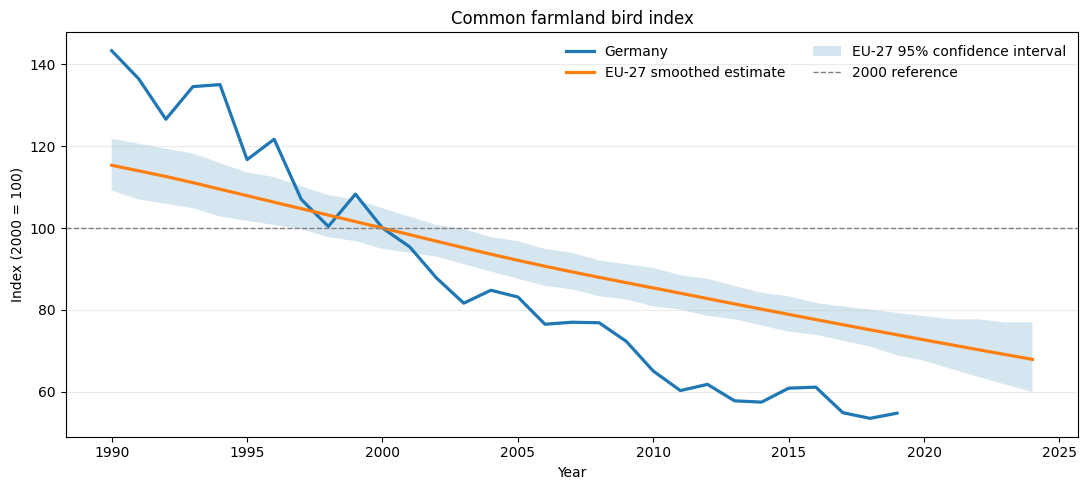

In [8]:
germany = birds_country.query("country == 'DE'")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(germany["year"], germany["bird_index"], label="Germany", linewidth=2.3)
ax.plot(
    eu_bird_benchmark["year"],
    eu_bird_benchmark["eu_smoothed"],
    label="EU-27 smoothed estimate",
    linewidth=2.3,
)
ax.fill_between(
    eu_bird_benchmark["year"],
    eu_bird_benchmark["eu_lower_95"],
    eu_bird_benchmark["eu_upper_95"],
    alpha=0.18,
    label="EU-27 95% confidence interval",
)
ax.axhline(100, color="grey", linestyle="--", linewidth=1, label="2000 reference")
ax.set(title="Common farmland bird index", xlabel="Year", ylabel="Index (2000 = 100)")
ax.legend(frameon=False, ncols=2)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


Index explanation:

$$\text{Index}(t) = \frac{\text{estimated bird population in year } t}{\text{estimated bird population in 2000}} \times 100$$

For Germany's Index, in three checking points:
- Year 2000: 100.00
- Year 2010: 65.02
- Year 2019: 54.72


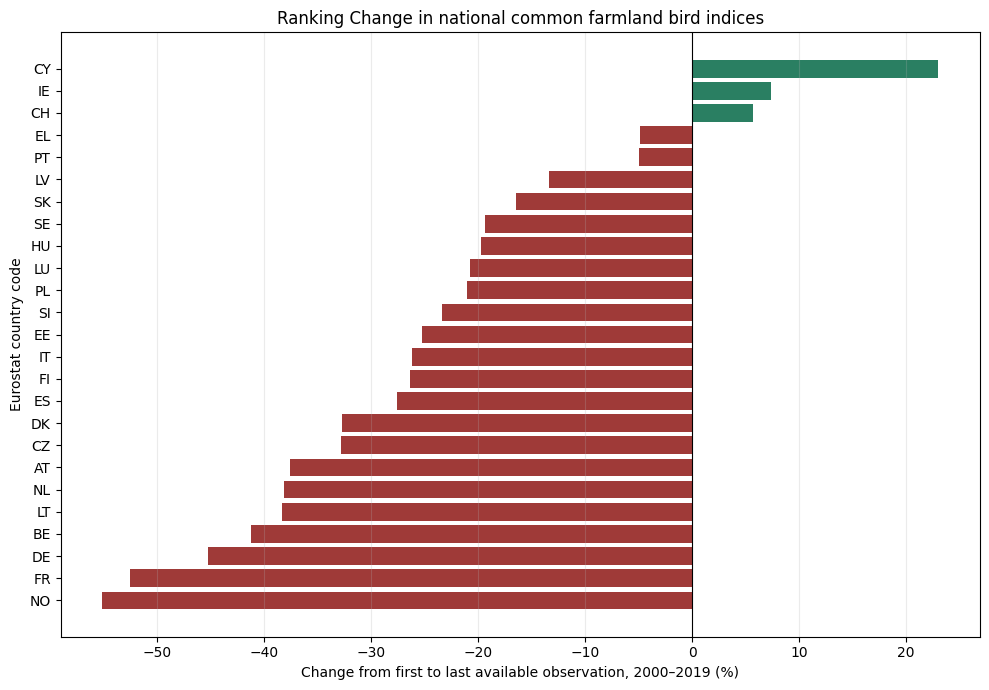

In [9]:
plot_data = country_trends_2000_2019.sort_values("change_pct")

fig, ax = plt.subplots(figsize=(10, 7))
colors = np.where(plot_data["change_pct"] < 0, "#9F3A38", "#2A7F62")
ax.barh(plot_data["country"], plot_data["change_pct"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    title="Ranking Change in national common farmland bird indices",
    xlabel="Change from first to last available observation, 2000–2019 (%)",
    ylabel="Eurostat country code",
)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()


Only **CY** *(Cyprus), **IE** (Ireland) and **CH** (Switzerland) observed positive Index of farmland bird population. On a second stage of the study we will look to indicators such as Bio Farming and Pesticede sales, to find correlations with the Index drop of most countries including Germany in comparison with these three.

## 8. Export other DataFrames for possible analsis

The exports keep the data at clearly defined grains:

- `birds_country_long.csv`: one national bird index per country-year;
- `eu_farmland_bird_benchmark.csv`: one EU benchmark row per year;
- `protected_terrestrial_long.csv`: one protected-area percentage per country-year;
- `bird_country_year_panel.csv`: merged descriptive panel, including missing predictors;
- `bird_model_panel_observed.csv`: complete rows for the current protected-area model;
- `country_trends_2000_2019.csv`: country-level trend summary; and
- `data_quality_audit.csv`: parsing and quality-control counts.


In [70]:
output_dir = Path("outputs/dataframes")
output_dir.mkdir(parents=True, exist_ok=True)

exports = {
    "birds_country_long.csv": birds_country,
    "eu_farmland_bird_benchmark.csv": eu_bird_benchmark,
    "protected_terrestrial_long.csv": protected_terrestrial,
    "bird_country_year_panel.csv": bird_panel,
    "bird_model_panel_observed.csv": model_panel_observed,
    "country_trends_2000_2019.csv": country_trends_2000_2019,
    "data_quality_audit.csv": audit,
}

for filename, dataframe in exports.items():
    dataframe.to_csv(output_dir / filename, index=False)

export_summary = pd.DataFrame(
    {
        "file": exports.keys(),
        "rows": [len(df) for df in exports.values()],
        "columns": [df.shape[1] for df in exports.values()],
    }
)

export_summary
display(bird_panel.head(), model_panel_observed.head())


,country,year,bird_index,bird_flag,eu_unsmoothed,eu_smoothed,eu_lower_95,eu_upper_95,protected_terrestrial_pct,protected_area_flag,bird_minus_eu,bird_change_pct
0,AT,1998,100.00,<NA>,101.79,103.16,108.06,97.78,<NA>,<NA>,-3.16,<NA>
1,AT,1999,102.30,<NA>,102.88,101.58,106.98,96.80,<NA>,<NA>,0.72,2.30
2,AT,2000,98.50,d,99.27,100.00,104.86,94.89,<NA>,<NA>,-1.50,-3.71
3,AT,2001,91.30,d,97.72,98.39,102.79,93.94,<NA>,<NA>,-7.09,-7.31
4,AT,2002,92.80,d,90.89,96.77,100.75,93.01,<NA>,<NA>,-3.97,1.64


,country,year,bird_index,bird_flag,eu_unsmoothed,eu_smoothed,eu_lower_95,eu_upper_95,protected_terrestrial_pct,protected_area_flag,bird_minus_eu,bird_change_pct
0,AT,2011,67.70,d,84.78,84.06,88.47,80.05,27.50,<NA>,-16.36,-3.70
1,AT,2012,68.70,d,82.74,82.75,87.59,78.47,27.90,<NA>,-14.05,1.48
2,AT,2013,63.00,d,79.64,81.44,85.86,77.69,28.00,<NA>,-18.44,-8.30
3,AT,2014,59.80,d,80.93,80.16,84.16,76.15,28.00,<NA>,-20.36,-5.08
4,AT,2015,62.90,d,81.61,78.88,83.32,74.64,28.10,<NA>,-15.98,5.18


## 9. Next stage

The present panel can describe national bird trajectories and their relationship with protected-area coverage. It is not yet a robust agricultural-pressure model because protected-area percentage changes slowly and is only available from 2011.

The next additions should be reshaped with the same function and merged on `country` and `year`:

1. `sdg_02_40`: percentage of utilised agricultural area under organic farming;
2. `aei_fm_salpest09`: Pesticide sales, total kilograms sold
3. `tag00025`: `Utilised agricultural area: thousand hectares, used to convert pesticide sales into kilograms per hectare.

Before fitting a model we need to:

- measure country-year overlap after every join;
- keep flags rather than discarding them silently;
- avoid treating an index as an absolute bird count;
- compare a country-and-year baseline with models containing environmental indicators;
- use a time-based or country-grouped validation split rather than a random row split; and
- describe model results as associations, not causal effects.


## 10. Add agricultural indicators from the Eurostat API

The predictive part uses three environmental indicators:

- **Organic farming:** percentage of utilised agricultural area under organic management (`sdg_02_40`).
- **Pesticide sales:** total kilograms sold (`aei_fm_salpest09`).
- **Utilised agricultural area:** thousand hectares (`tag00025`), used to convert pesticide sales into kilograms per hectare.

Pesticide totals should not be compared directly between large and small countries. The derived intensity is:

$$\text{Pesticide Intensity} = \frac{\text{pesticide sales in kg}}{\text{utilised agricultural area in thousand hectares}} \times 1000$$


The function below reads Eurostat's JSON-stat response using only Python's standard library, so it also works in environments where `requests` is unavailable.


In [37]:
import json
import urllib.parse
import urllib.request


EUROSTAT_API = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"


def fetch_eurostat_jsonstat(dataset_code, filters=None, timeout=90):
    # Fetch a filtered Eurostat dataset and return observations in long format.
    params = {"lang": "en"}
    if filters:
        params.update(filters)
    url = f"{EUROSTAT_API}/{dataset_code}?{urllib.parse.urlencode(params)}"

    with urllib.request.urlopen(url, timeout=timeout) as response:
        payload = json.load(response)

    dimensions = payload["id"]
    sizes = payload["size"]
    dimension_codes = []

    for dimension in dimensions:
        category_index = payload["dimension"][dimension]["category"]["index"]
        if isinstance(category_index, dict):
            ordered_codes = [
                code_value
                for code_value, _ in sorted(category_index.items(), key=lambda item: item[1])
            ]
        else:
            ordered_codes = list(category_index)
        dimension_codes.append(ordered_codes)

    observations = []
    statuses = payload.get("status", {})
    for flat_index_text, value in payload.get("value", {}).items():
        flat_index = int(flat_index_text)
        remaining = flat_index
        coordinates = []
        for size in reversed(sizes):
            coordinates.append(remaining % size)
            remaining //= size
        coordinates.reverse()

        row = {
            dimension: dimension_codes[position][coordinate]
            for position, (dimension, coordinate) in enumerate(
                zip(dimensions, coordinates)
            )
        }
        row["value"] = value
        row["flag"] = statuses.get(flat_index_text, pd.NA)
        observations.append(row)

    result = pd.DataFrame(observations)
    result.attrs["dataset_code"] = dataset_code
    result.attrs["dataset_label"] = payload.get("label", dataset_code)
    result.attrs["source_url"] = url
    return result


organic_raw = fetch_eurostat_jsonstat(
    "sdg_02_40",
    {
        "unit": "PC_UAA",
        "crops": "UAAXK0000",
        "agprdmet": "TOTAL",
    },
)

display(organic_raw.head(10))


pesticide_raw = fetch_eurostat_jsonstat(
    "aei_fm_salpest09",
    {"pesticid": "TOTAL", "unit": "KG"},
)
display(pesticide_raw.head(10))

uaa_raw = fetch_eurostat_jsonstat(
    "tag00025",
    {"crops": "UAA", "strucpro": "MAR_THS_HA"},
)
display(uaa_raw.head(10))

pd.DataFrame(
    {
        "dataset": ["sdg_02_40", "aei_fm_salpest09", "tag00025"],
        "meaning": [
            "Organic farming share",
            "Total pesticide sales",
            "Utilised agricultural area",
        ],
        "retrieved_rows": [len(organic_raw), len(pesticide_raw), len(uaa_raw)],
    }
)


,freq,unit,crops,agprdmet,geo,time,value,flag
0,A,PC_UAA,UAAXK0000,TOTAL,AL,2021,0.09,<NA>
1,A,PC_UAA,UAAXK0000,TOTAL,AL,2022,0.06,<NA>
2,A,PC_UAA,UAAXK0000,TOTAL,AL,2023,0.07,<NA>
3,A,PC_UAA,UAAXK0000,TOTAL,AL,2024,0.07,<NA>
4,A,PC_UAA,UAAXK0000,TOTAL,AT,2000,13.80,<NA>
5,A,PC_UAA,UAAXK0000,TOTAL,AT,2001,14.00,<NA>
6,A,PC_UAA,UAAXK0000,TOTAL,AT,2002,14.50,<NA>
7,A,PC_UAA,UAAXK0000,TOTAL,AT,2003,15.40,<NA>
8,A,PC_UAA,UAAXK0000,TOTAL,AT,2004,16.00,<NA>
9,A,PC_UAA,UAAXK0000,TOTAL,AT,2005,16.70,<NA>


,freq,pesticid,unit,geo,time,value,flag
0,A,TOTAL,KG,AT,2011,3448274,<NA>
1,A,TOTAL,KG,AT,2012,3557023,<NA>
2,A,TOTAL,KG,AT,2013,3097442,<NA>
3,A,TOTAL,KG,AT,2014,3373223,<NA>
4,A,TOTAL,KG,AT,2015,3777617,<NA>
5,A,TOTAL,KG,AT,2016,4361487,<NA>
6,A,TOTAL,KG,AT,2017,4624882,<NA>
7,A,TOTAL,KG,AT,2018,5279544,<NA>
8,A,TOTAL,KG,AT,2019,4954458,<NA>
9,A,TOTAL,KG,AT,2020,5566034,<NA>


,freq,crops,strucpro,geo,time,value,flag
0,A,UAA,MAR_THS_HA,AL,2014,"1,174.30",<NA>
1,A,UAA,MAR_THS_HA,AL,2015,"1,175.00",<NA>
2,A,UAA,MAR_THS_HA,AL,2016,"1,181.70",<NA>
3,A,UAA,MAR_THS_HA,AL,2017,"1,174.10",<NA>
4,A,UAA,MAR_THS_HA,AL,2018,"1,174.00",<NA>
5,A,UAA,MAR_THS_HA,AL,2019,"1,174.10",<NA>
6,A,UAA,MAR_THS_HA,AL,2020,"1,165.70",<NA>
7,A,UAA,MAR_THS_HA,AL,2021,"1,165.60",<NA>
8,A,UAA,MAR_THS_HA,AL,2022,"1,164.40",<NA>
9,A,UAA,MAR_THS_HA,AL,2023,"1,044.60",<NA>


,dataset,meaning,retrieved_rows
0,sdg_02_40,Organic farming share,746
1,aei_fm_salpest09,Total pesticide sales,385
2,tag00025,Utilised agricultural area,460


Let's understand each Eurostat Data set Separately
1. The Eurostat dataset (sdg_02_40) measures the share of agricultural land used for organic farming. Each row represents one geographical area in one year.
| Column     | Meaning                                    | Example                                                            |
| ---------- | ------------------------------------------ | ------------------------------------------------------------------ |
| `freq`     | Reporting frequency                        | `A` = annual                                                       |
| `unit`     | Unit used for the measurement              | `PC_UAA` = percentage of total utilised agricultural area          |
| `crops`    | Agricultural land category included        | `UAAXK0000` = utilised agricultural area excluding kitchen gardens |
| `agprdmet` | Agricultural production method             | `TOTAL` = fully organic and under conversion to organic            |
| `geo`      | Country or European geographical aggregate | `DE` = Germany                                                     |
| `time`     | Observation year                           | `2023`                                                             |
| `value`    | Numeric result                             | `11.16`                                                            |
| `flag`     | Status or quality annotation               | `e` = estimated                                                    |


In [77]:
#To match the birds data set, rename and select columns

organic_farming = (
    organic_raw
    .rename(
        columns={
            "geo": "country",
            "time": "year",
            "value": "organic_farming_pct",
            "flag": "organic_flag"
        }
    )
    .loc[
        lambda df: df["country"] != "EU27_2020",
        [
            "country",
            "year",
            "organic_farming_pct",
            "organic_flag"
        ]
    ]
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)

organic_farming["year"] = pd.to_numeric(
    organic_farming["year"],
    errors="raise"
).astype(int)

organic_farming.head(20)

,country,year,organic_farming_pct,organic_flag
0,AL,2021,0.09,<NA>
1,AL,2022,0.06,<NA>
2,AL,2023,0.07,<NA>
3,AL,2024,0.07,<NA>
4,AT,2000,13.80,<NA>
5,AT,2001,14.00,<NA>
6,AT,2002,14.50,<NA>
7,AT,2003,15.40,<NA>
8,AT,2004,16.00,<NA>
9,AT,2005,16.70,<NA>


We keep the organic_flag parameter becaus it contains status or comparatability of an observation:
| Flag          | Meaning                                           |
| ------------- | ------------------------------------------------- |
| Missing/`NaN` | No special status flag                            |
| `e`           | Estimated                                         |
| `p`           | Provisional                                       |
| `d`           | Definition differs; consult metadata              |
| `b`           | Break in time series                              |
| `be`          | Both a break in the series and an estimated value |


2. To include the pesticides information in `aei_fm_salpest09` we observe that pesticid: "TOTAL", means this requests total pesticide sales rather than an individual pesticide group such as:

-Fungicides
-Herbicides
-Insecticides
-Molluscicides
-Plant-growth regulators

Using TOTAL prevents multiple pesticide-category rows for the same country and year.

3. In the same workflow we analyze `tag00025`: `Utilised agricultural area: thousand hectares, used to convert pesticide sales into kilograms per hectare.


In [40]:
print("Pesticide dataset columns:")
print(pesticide_raw.columns.tolist())

print("\nPesticide categories:")
print(pesticide_raw["pesticid"].value_counts(dropna=False))

print("\nPesticide units:")
print(pesticide_raw["unit"].value_counts(dropna=False))


print("\nAgricultural-area dataset columns:")
print(uaa_raw.columns.tolist())

print("\nAgricultural-area categories:")
print(uaa_raw["crops"].value_counts(dropna=False))

print("\nArea measurement types:")
print(uaa_raw["strucpro"].value_counts(dropna=False))

Pesticide dataset columns:
['freq', 'pesticid', 'unit', 'geo', 'time', 'value', 'flag']

Pesticide categories:
pesticid
TOTAL    385
Name: count, dtype: int64

Pesticide units:
unit
KG    385
Name: count, dtype: int64

Agricultural-area dataset columns:
['freq', 'crops', 'strucpro', 'geo', 'time', 'value', 'flag']

Agricultural-area categories:
crops
UAA    460
Name: count, dtype: int64

Area measurement types:
strucpro
MAR_THS_HA    460
Name: count, dtype: int64


In [41]:
#confirming dimensions
assert pesticide_raw["pesticid"].eq("TOTAL").all()
assert pesticide_raw["unit"].eq("KG").all()

assert uaa_raw["crops"].eq("UAA").all()
assert uaa_raw["strucpro"].eq("MAR_THS_HA").all()

In [42]:
pesticide_sales = (
    pesticide_raw
    .rename(
        columns={
            "geo": "country",
            "time": "year",
            "value": "pesticide_sales_kg",
            "flag": "pesticide_flag"
        }
    )
    .copy()
)

In [44]:
#Converting year and kg to numeric

pesticide_sales["year"] = pd.to_numeric(
    pesticide_sales["year"],
    errors="raise"
).astype(int)

pesticide_sales["pesticide_sales_kg"] = pd.to_numeric(
    pesticide_sales["pesticide_sales_kg"],
    errors="coerce"
)

Now in agricultural-area data

In [45]:
agricultural_area = (
    uaa_raw
    .rename(
        columns={
            "geo": "country",
            "time": "year",
            "value": "uaa_thousand_ha",
            "flag": "uaa_flag"
        }
    )
    .copy()
)

In [46]:
agricultural_area["year"] = pd.to_numeric(
    agricultural_area["year"],
    errors="raise"
).astype(int)

agricultural_area["uaa_thousand_ha"] = pd.to_numeric(
    agricultural_area["uaa_thousand_ha"],
    errors="coerce"
)

Both data set might contain
EU27_2020
EA20
EFTA
Which are group of countries and not countries, and they shouldn't enter in a country level model

In [47]:
AGGREGATE_GEOS = {
    "EU27_2020",
    "EU28",
    "EA19",
    "EA20",
    "EFTA",
    "EEA30_2007",
    "CC4_2020",
    "CC3_2007"
}

In [48]:
pesticide_sales = pesticide_sales.loc[
    ~pesticide_sales["country"].isin(AGGREGATE_GEOS),
    [
        "country",
        "year",
        "pesticide_sales_kg",
        "pesticide_flag"
    ]
].copy()

agricultural_area = agricultural_area.loc[
    ~agricultural_area["country"].isin(AGGREGATE_GEOS),
    [
        "country",
        "year",
        "uaa_thousand_ha",
        "uaa_flag"
    ]
].copy()

Checking missing values, flags and duplicates

In [49]:
pesticide_audit = pd.Series({
    "rows": len(pesticide_sales),
    "countries": pesticide_sales["country"].nunique(),
    "first_year": pesticide_sales["year"].min(),
    "last_year": pesticide_sales["year"].max(),
    "missing_values": pesticide_sales["pesticide_sales_kg"].isna().sum(),
    "flagged_values": pesticide_sales["pesticide_flag"].notna().sum(),
    "duplicate_keys": pesticide_sales.duplicated(
        ["country", "year"]
    ).sum()
})

uaa_audit = pd.Series({
    "rows": len(agricultural_area),
    "countries": agricultural_area["country"].nunique(),
    "first_year": agricultural_area["year"].min(),
    "last_year": agricultural_area["year"].max(),
    "missing_values": agricultural_area["uaa_thousand_ha"].isna().sum(),
    "flagged_values": agricultural_area["uaa_flag"].notna().sum(),
    "duplicate_keys": agricultural_area.duplicated(
        ["country", "year"]
    ).sum()
})

display(
    pd.concat(
        {
            "pesticide_sales": pesticide_audit,
            "agricultural_area": uaa_audit
        },
        axis=1
    ).T
)

,rows,countries,first_year,last_year,missing_values,flagged_values,duplicate_keys
pesticide_sales,385,32,2011,2024,0,1,0
agricultural_area,448,38,2013,2024,0,32,0


In [50]:
#inspecting flags
display(
    pesticide_sales["pesticide_flag"]
    .value_counts(dropna=False)
    .rename_axis("flag")
    .reset_index(name="observations")
)

display(
    agricultural_area["uaa_flag"]
    .value_counts(dropna=False)
    .rename_axis("flag")
    .reset_index(name="observations")
)

,flag,observations
0,<NA>,384
1,b,1


,flag,observations
0,<NA>,416
1,e,20
2,p,11
3,b,1


Checking duplicates

In [52]:
pesticide_duplicates = pesticide_sales.loc[
    pesticide_sales.duplicated(
        ["country", "year"],
        keep=False
    )
]

uaa_duplicates = agricultural_area.loc[
    agricultural_area.duplicated(
        ["country", "year"],
        keep=False
    )
]

display(pesticide_duplicates.sum())
display(uaa_duplicates.sum())

,0
country,0
year,0
pesticide_sales_kg,0
pesticide_flag,0


,0
country,0
year,0
uaa_thousand_ha,0.00
uaa_flag,0


Checking country/year matches in both data sets

In [54]:
merge_diagnostic = pesticide_sales.merge(
    agricultural_area,
    on=["country", "year"],
    how="outer",
    indicator=True,
    validate="one_to_one"
)

display(
    merge_diagnostic["_merge"]
    .value_counts()
    .rename_axis("merge_status")
    .reset_index(name="rows")
)

,merge_status,rows
0,both,335
1,right_only,113
2,left_only,50


So we will be able to merge with 335 country/year matching rows in order to obtain information about the pesticide intensity.

In [60]:
pesticide_intensity = pesticide_sales.merge(
    agricultural_area,
    on=["country", "year"],
    how="inner",
    validate="one_to_one"
)
pesticide_intensity["uaa_ha"] = (
    pesticide_intensity["uaa_thousand_ha"] * 1000
)
pesticide_intensity["pesticide_intensity_kg_ha"] = (
    pesticide_intensity["pesticide_sales_kg"] / pesticide_intensity["uaa_ha"]
)
pesticide_intensity.head(20)

,country,year,pesticide_sales_kg,pesticide_flag,uaa_thousand_ha,uaa_flag,uaa_ha,pesticide_intensity_kg_ha
0,AT,2013,3097442,<NA>,"2,862.44",<NA>,"2,862,440.00",1.08
1,AT,2014,3373223,<NA>,"2,716.16",<NA>,"2,716,160.00",1.24
2,AT,2015,3777617,<NA>,"2,720.40",<NA>,"2,720,400.00",1.39
3,AT,2016,4361487,<NA>,"2,688.83",<NA>,"2,688,830.00",1.62
4,AT,2017,4624882,<NA>,"2,655.56",<NA>,"2,655,560.00",1.74
5,AT,2018,5279544,<NA>,"2,653.84",<NA>,"2,653,840.00",1.99
6,AT,2019,4954458,<NA>,"2,652.22",<NA>,"2,652,220.00",1.87
7,AT,2020,5566034,<NA>,"2,646.96",<NA>,"2,646,960.00",2.10
8,AT,2021,5790560,<NA>,"2,602.49",<NA>,"2,602,490.00",2.23
9,AT,2022,6068732,<NA>,"2,599.51",<NA>,"2,599,510.00",2.33


In [64]:
#Checking for invalid input data
invalid_pesticide_data = (
    pesticide_intensity["pesticide_sales_kg"].isna()
    | pesticide_intensity["pesticide_sales_kg"].lt(0)
    | pesticide_intensity["uaa_ha"].isna()
    | pesticide_intensity["uaa_ha"].le(0)
)

display(
    pesticide_intensity.loc[
        invalid_pesticide_data,
        [
            "country",
            "year",
            "pesticide_sales_kg",
            "uaa_thousand_ha",
            "pesticide_flag",
            "uaa_flag"
        ]
    ]
)


,country,year,pesticide_sales_kg,uaa_thousand_ha,pesticide_flag,uaa_flag


Alles gut!

Creating the final Pesticides Intensity Data Frame

In [66]:
pesticide_intensity_ready = (
    pesticide_intensity[
        [
            "country",
            "year",
            "pesticide_sales_kg",
            "uaa_thousand_ha",
            "uaa_ha",
            "pesticide_kg_per_ha",
            "pesticide_flag",
            "uaa_flag"
        ]
    ]
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)

display(pesticide_intensity_ready.head(10))

print("Rows:", len(pesticide_intensity_ready))
print(
    "Countries:",
    pesticide_intensity_ready["country"].nunique()
)
print(
    "Years:",
    pesticide_intensity_ready["year"].min(),
    "to",
    pesticide_intensity_ready["year"].max()
)
print(
    "Missing intensity:",
    pesticide_intensity_ready[
        "pesticide_kg_per_ha"
    ].isna().sum()
)
print(
    "Duplicate country-years:",
    pesticide_intensity_ready.duplicated(
        ["country", "year"]
    ).sum()
)

,country,year,pesticide_sales_kg,uaa_thousand_ha,uaa_ha,pesticide_kg_per_ha,pesticide_flag,uaa_flag
0,AT,2013,3097442,"2,862.44","2,862,440.00",1.08,<NA>,<NA>
1,AT,2014,3373223,"2,716.16","2,716,160.00",1.24,<NA>,<NA>
2,AT,2015,3777617,"2,720.40","2,720,400.00",1.39,<NA>,<NA>
3,AT,2016,4361487,"2,688.83","2,688,830.00",1.62,<NA>,<NA>
4,AT,2017,4624882,"2,655.56","2,655,560.00",1.74,<NA>,<NA>
5,AT,2018,5279544,"2,653.84","2,653,840.00",1.99,<NA>,<NA>
6,AT,2019,4954458,"2,652.22","2,652,220.00",1.87,<NA>,<NA>
7,AT,2020,5566034,"2,646.96","2,646,960.00",2.10,<NA>,<NA>
8,AT,2021,5790560,"2,602.49","2,602,490.00",2.23,<NA>,<NA>
9,AT,2022,6068732,"2,599.51","2,599,510.00",2.33,<NA>,<NA>


Rows: 335
Countries: 32
Years: 2013 to 2024
Missing intensity: 0
Duplicate country-years: 0


## 11. Create the Model Ready Data Frame

Now we have these three Data Frames


*   birds_country
*   organic_farming
*   pesticide_intensity_ready








We start with the birds_country data frame and using left joins because the bird index is your target variable. This preserves all bird observations and shows where explanatory variables are unavailable.

In [86]:
birds_environment_panel = (
    birds_country
    .merge(
        organic_farming[
            [
                "country",
                "year",
                "organic_farming_pct",
                "organic_flag"
            ]
        ],
        on=["country", "year"],
        how="left",
        validate="one_to_one"
    )
    .merge(
        pesticide_intensity_ready,
        on=["country", "year"],
        how="left",
        validate="one_to_one"
    )
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)

In [87]:
display(birds_environment_panel.head(10))

print("Panel shape:", birds_environment_panel.shape)

display(
    birds_environment_panel[
        [
            "bird_index",
            "organic_farming_pct",
            "pesticide_kg_per_ha"
        ]
    ]
    .isna()
    .sum()
    .rename("missing_values")
    .to_frame()
)

,country,year,bird_index,bird_flag,organic_farming_pct,organic_flag,pesticide_sales_kg,uaa_thousand_ha,uaa_ha,pesticide_kg_per_ha,pesticide_flag,uaa_flag
0,AT,1998,100.00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AT,1999,102.30,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AT,2000,98.50,d,13.80,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
3,AT,2001,91.30,d,14.00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
4,AT,2002,92.80,d,14.50,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
5,AT,2003,87.80,d,15.40,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
6,AT,2004,90.40,d,16.00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
7,AT,2005,92.50,d,16.70,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
8,AT,2006,85.00,d,16.70,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
9,AT,2007,82.10,d,17.00,<NA>,NaN,NaN,NaN,NaN,NaN,NaN


Panel shape: (643, 12)


,missing_values
bird_index,0
organic_farming_pct,152
pesticide_kg_per_ha,420


DATA SET FOR THE MODEL

In [89]:
model_data = (
    birds_environment_panel
    .dropna(
        subset=[
            "bird_index",
            "organic_farming_pct",
            "pesticide_kg_per_ha"
        ]
    )
    .reset_index(drop=True)
)
display(model_data.head(10))
model_data.info()

,country,year,bird_index,bird_flag,organic_farming_pct,organic_flag,pesticide_sales_kg,uaa_thousand_ha,uaa_ha,pesticide_kg_per_ha,pesticide_flag,uaa_flag
0,AT,2013,63.00,d,18.40,<NA>,"3,097,442.00","2,862.44","2,862,440.00",1.08,<NA>,<NA>
1,AT,2014,59.80,d,19.35,<NA>,"3,373,223.00","2,716.16","2,716,160.00",1.24,<NA>,<NA>
2,AT,2015,62.90,d,20.30,<NA>,"3,777,617.00","2,720.40","2,720,400.00",1.39,<NA>,<NA>
3,AT,2016,58.40,d,21.25,<NA>,"4,361,487.00","2,688.83","2,688,830.00",1.62,<NA>,<NA>
4,AT,2017,60.70,d,23.37,<NA>,"4,624,882.00","2,655.56","2,655,560.00",1.74,<NA>,<NA>
5,AT,2018,55.20,d,24.08,<NA>,"5,279,544.00","2,653.84","2,653,840.00",1.99,<NA>,<NA>
6,AT,2019,61.50,d,25.33,<NA>,"4,954,458.00","2,652.22","2,652,220.00",1.87,<NA>,<NA>
7,AT,2020,61.70,d,25.69,<NA>,"5,566,034.00","2,646.96","2,646,960.00",2.10,<NA>,<NA>
8,BE,2013,72.88,<NA>,4.67,<NA>,"6,335,282.00","1,338.57","1,338,570.00",4.73,<NA>,<NA>
9,BE,2014,70.43,<NA>,5.00,<NA>,"7,180,178.00","1,333.40","1,333,400.00",5.38,<NA>,<NA>


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              218 non-null    object 
 1   year                 218 non-null    int64  
 2   bird_index           218 non-null    Float64
 3   bird_flag            87 non-null     string 
 4   organic_farming_pct  218 non-null    float64
 5   organic_flag         12 non-null     object 
 6   pesticide_sales_kg   218 non-null    float64
 7   uaa_thousand_ha      218 non-null    float64
 8   uaa_ha               218 non-null    float64
 9   pesticide_kg_per_ha  218 non-null    float64
 10  pesticide_flag       0 non-null      object 
 11  uaa_flag             6 non-null      object 
dtypes: Float64(1), float64(5), int64(1), object(4), string(1)
memory usage: 20.8+ KB


One scientific limitation should remain explicit: pesticide_kg_per_ha represents pesticide sales per agricultural hectare, not pesticides actually applied in that country-year. Sales may differ from use because of storage, trade, reporting practices and non-agricultural professional applications. It is a reasonable national pressure proxy, but not a direct exposure measurement.